In [1]:
import pandas as pd

hpa = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_hpa.csv")  
print(hpa.shape)
print(hpa.columns.tolist())
hpa.head()

(24315372, 10)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'source', 'tpm', 'pTPM', 'nTPM', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,source,tpm,pTPM,nTPM,log2_tpm_plus1,is_expressed
0,ACH-001001,CVCL_2270,ENSG00000000003,TSPAN6,hpa,22.0,27.6,25.9,4.523562,True
1,ACH-000956,CVCL_1045,ENSG00000000003,TSPAN6,hpa,2.8,3.6,2.7,1.925999,True
2,ACH-000948,CVCL_1046,ENSG00000000003,TSPAN6,hpa,6.2,7.5,7.5,2.847997,True
3,ACH-000011,CVCL_7935,ENSG00000000003,TSPAN6,hpa,14.2,18.7,25.4,3.925999,True
4,ACH-000026,CVCL_7937,ENSG00000000003,TSPAN6,hpa,13.0,17.1,18.5,3.807355,True


In [2]:
print(hpa["source"].unique())

['hpa']


In [3]:
geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")  
print(geo.shape)
print(geo.columns.tolist())
geo.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_120616\1781234455.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")


(65059038, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'GSM_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,GSM_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-000558,CVCL_0131,ENSG00000000003,GSM101610,geo,33.615700,5.113355,True
1,ACH-000558,CVCL_0131,ENSG00000000005,GSM101610,geo,40.925682,5.389762,True
2,ACH-000558,CVCL_0131,ENSG00000000419,GSM101610,geo,2182.281250,11.092282,True
3,ACH-000558,CVCL_0131,ENSG00000000457,GSM101610,geo,58.934814,5.905322,True
4,ACH-000558,CVCL_0131,ENSG00000000460,GSM101610,geo,136.418900,7.102437,True


In [4]:
# does one cell line have multiple GSM samples?
geo.groupby("ACH_ID")["GSM_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-002875    108
ACH-001188     67
ACH-000019     49
ACH-000768     41
ACH-000681     31
Name: GSM_ID, dtype: int64

In [5]:
depmap = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_depmap.csv")
print(depmap.shape)
print(depmap.columns.tolist())
depmap.head()

(80039310, 9)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'PR_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,PR_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-001113,CVCL_5480,ENSG00000000005,TNMD,PR-AdBjpG,depmap,0.0,0.000000,False
1,ACH-001289,CVCL_RS25,ENSG00000000005,TNMD,PR-I2AzwG,depmap,0.5,0.584963,False
2,ACH-001339,CVCL_2408,ENSG00000000005,TNMD,PR-5ekAAC,depmap,0.0,0.000000,False
3,ACH-001538,CVCL_M261,ENSG00000000005,TNMD,PR-I21681,depmap,0.0,0.000000,False
4,ACH-000242,CVCL_0036,ENSG00000000005,TNMD,PR-i9DRP1,depmap,0.0,0.000000,False


In [6]:
# does one cell line have multiple PR Ids?
depmap.groupby("ACH_ID")["PR_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-000029    2
ACH-000556    2
ACH-000328    2
ACH-000700    2
ACH-000517    2
Name: PR_ID, dtype: int64

In [7]:
# check the PR split 
print(depmap.groupby("ACH_ID")["PR_ID"].nunique().value_counts())

PR_ID
1    1463
2      16
Name: count, dtype: int64


In [8]:
print("depmap:", depmap.shape)
print("hpa:", hpa.shape)
print("geo:", geo.shape)

depmap: (80039310, 9)
hpa: (24315372, 10)
geo: (65059038, 8)


In [9]:
import numpy as np

for name, df, raw_col in [("depmap", depmap, "tpm"),
                          ("hpa",    hpa,    "tpm"),
                          ("geo",    geo,    "tpm")]:
    s = df.head(200000)
    diff = (np.log2(s[raw_col] + 1) - s["log2_tpm_plus1"]).abs().max()
    print(f"{name:7s} max diff = {diff}")

depmap  max diff = 8.881784197001252e-16
hpa     max diff = 1.7763568394002505e-15
geo     max diff = 1.7763568394002505e-15


In [58]:
target = "ENSG00000141736"   # ERBB2 / HER2
# pull the gene's rows from each source
dm_sub  = depmap[depmap["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]
hpa_sub = hpa[hpa["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]
geo_sub = geo[geo["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]

# aggregate replicates per cell line
def aggregate_source(df, name, how="median"):
    agg = (df.groupby("ACH_ID")["log2_tpm_plus1"]
             .agg(value=how, spread="std", n_reps="count")
             .reset_index())
    agg["spread"] = agg["spread"].fillna(0)          # single replicate -> no spread
    agg["percentile"] = agg["value"].rank(pct=True) * 100
    agg = agg.rename(columns={
        "value":      f"{name}_value",
        "spread":     f"{name}_spread",
        "n_reps":     f"{name}_n_reps",
        "percentile": f"{name}_percentile",
    })
    return agg

dm_agg  = aggregate_source(dm_sub,  "depmap")
hpa_agg = aggregate_source(hpa_sub, "hpa")
geo_agg = aggregate_source(geo_sub, "geo")      # median matters most here

# one row per cell line, all three sources side by side
rna = dm_agg.merge(hpa_agg, on="ACH_ID", how="outer") \
            .merge(geo_agg, on="ACH_ID", how="outer")

print("Cell lines:", len(rna))
print("\nReplicates per cell line (max):")
for s in ["depmap", "hpa", "geo"]:
    col = f"{s}_n_reps"
    print(f"  {s:7s} max={rna[col].max():.0f}  mean={rna[col].mean():.2f}")

rna.head()

Cell lines: 1581

Replicates per cell line (max):
  depmap  max=2  mean=1.01
  hpa     max=8  mean=1.01
  geo     max=108  mean=4.10


,ACH_ID,depmap_value,depmap_spread,depmap_n_reps,depmap_percentile,hpa_value,hpa_spread,hpa_n_reps,hpa_percentile,geo_value,geo_spread,geo_n_reps,geo_percentile
0,ACH-000001,4.991862,0.0,1.0,62.204192,5.368070,0.0,1.0,72.081448,4.860055,0.800435,15.0,9.337861
1,ACH-000002,1.244887,0.0,1.0,2.129817,1.632268,0.0,1.0,5.927602,5.063641,0.283789,2.0,16.638370
2,ACH-000003,5.096768,0.0,1.0,65.382015,4.887525,0.0,1.0,56.651584,6.396557,0.590848,10.0,72.665535
3,ACH-000004,2.480265,0.0,1.0,15.821501,1.847997,0.0,1.0,8.597285,NaN,NaN,NaN,NaN
4,ACH-000005,2.090853,0.0,1.0,11.629479,2.232661,0.0,1.0,14.841629,4.856700,0.004436,2.0,9.168081


In [59]:
# Load harmonized proteomics data instead of the raw file
fact_prot = pd.read_csv("../../data/AZ_harmonized_data/fact_proteomics.csv")

print(fact_prot.shape)
print(fact_prot.columns.tolist())
fact_prot.head(10)

(4709250, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'uniprot_id', 'hugo_symbol', 'protein_intensity', 'is_detected', 'z_score']


,ACH_ID,CVCL_ID,ensembl_id,uniprot_id,hugo_symbol,protein_intensity,is_detected,z_score
0,ACH-000849,CVCL_0419,ENSG00000163694,A0AV96,RBM47,0.358567,True,0.263468
1,ACH-000441,CVCL_1692,ENSG00000163694,A0AV96,RBM47,-1.112410,True,-0.808447
2,ACH-000248,CVCL_1074,ENSG00000163694,A0AV96,RBM47,0.855575,True,0.625642
3,ACH-000684,CVCL_2983,ENSG00000163694,A0AV96,RBM47,0.061377,True,0.046903
4,ACH-000856,CVCL_1110,ENSG00000163694,A0AV96,RBM47,0.284258,True,0.209318
5,ACH-000348,CVCL_1666,ENSG00000163694,A0AV96,RBM47,-0.485070,True,-0.351298
6,ACH-000062,CVCL_1655,ENSG00000163694,A0AV96,RBM47,0.092390,True,0.069502
7,ACH-000650,CVCL_2075,ENSG00000163694,A0AV96,RBM47,-0.824035,True,-0.598306
8,ACH-000484,CVCL_1790,ENSG00000163694,A0AV96,RBM47,0.926286,True,0.677170
9,ACH-000625,CVCL_0326,ENSG00000163694,A0AV96,RBM47,1.323508,True,0.966630


In [60]:
# protein percentile for the target gene 
prot = fact_prot[fact_prot["ensembl_id"] == target][["ACH_ID", "protein_intensity", "is_detected"]].copy()
prot = prot.dropna(subset=["protein_intensity"])
prot["protein_percentile"] = prot["protein_intensity"].rank(pct=True) * 100

combined = rna.merge(
    prot[["ACH_ID", "protein_intensity", "protein_percentile", "is_detected"]],
    on="ACH_ID", how="left"
)

# one confidence per RNA source, paired with protein
def pairing(df, source):
    rna_pct  = df[f"{source}_percentile"]
    prot_pct = df["protein_percentile"]

    has_rna  = rna_pct.notna()
    has_prot = prot_pct.notna()

    # strength: mean of the two percentiles where both exist, else RNA alone
    strength = np.where(has_prot, (rna_pct + prot_pct) / 2, rna_pct)

    # agreement: penalise RNA/protein disagreement. 1.0 when protein absent
    gap = (rna_pct - prot_pct).abs() / 100
    agreement = np.where(has_prot, 1 / (1 + gap), 1.0)

    # coverage: 1.0 with both evidence types, 0.5 with RNA only
    coverage = np.where(has_prot, 1.0, 0.75)

    conf = np.where(has_rna, coverage * agreement, np.nan)
    return pd.Series(strength, index=df.index).where(has_rna), pd.Series(conf, index=df.index)

for s in ["depmap", "hpa", "geo"]:
    combined[f"{s}_strength"], combined[f"{s}_conf"] = pairing(combined, s)

# GEO only: penalise inconsistent replicates (coefficient of variation)
geo_cv = combined["geo_spread"] / combined["geo_value"].replace(0, np.nan)
combined["geo_conf"] = combined["geo_conf"] * (1 / (1 + geo_cv.fillna(0)))

# combine the three pairings
strength_cols = [f"{s}_strength" for s in ["depmap", "hpa", "geo"]]
conf_cols     = [f"{s}_conf"     for s in ["depmap", "hpa", "geo"]]

combined["rna_percentile"]   = combined[strength_cols].mean(axis=1)
combined["n_sources"]        = combined[strength_cols].notna().sum(axis=1)
combined["source_std"]       = combined[strength_cols].std(axis=1).fillna(0)
combined["confidence_score"] = (
      (combined["n_sources"] / 3)
    * (1 / (1 + combined["source_std"] / 100))
    * combined[conf_cols].mean(axis=1)
)

combined = combined.sort_values(["rna_percentile", "confidence_score"], ascending=[False, False])
print(combined.shape)
combined[["ACH_ID", "rna_percentile", "n_sources", "source_std", "protein_intensity", "confidence_score"] + conf_cols].head(10)

(1581, 26)


,ACH_ID,rna_percentile,n_sources,source_std,protein_intensity,confidence_score,depmap_conf,hpa_conf,geo_conf
675,ACH-000679,100.000000,2,0.000000,NaN,0.500000,0.750000,0.750000,NaN
425,ACH-000427,99.877490,3,0.114998,5.146808,0.978098,0.998650,0.999096,0.939922
478,ACH-000481,99.587990,3,0.098627,5.023633,0.996122,0.996593,0.995448,0.999272
1171,ACH-001393,99.459094,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
926,ACH-000930,99.416370,3,0.376227,NaN,0.730128,0.750000,0.750000,0.698624
824,ACH-000828,99.344219,3,0.321688,NaN,0.724952,0.750000,0.750000,0.681852
913,ACH-000917,99.264721,2,0.041190,4.811819,0.663712,0.996556,0.995400,NaN
115,ACH-000117,99.080933,3,0.080447,4.337748,0.977953,0.991473,0.990380,0.954367
550,ACH-000554,98.985515,3,1.055067,NaN,0.716110,0.750000,0.750000,0.670996
390,ACH-000392,98.904289,3,0.251826,NaN,0.742808,0.750000,0.750000,0.734035


In [61]:
def score_with_penalty(rna_df, prot_df, penalty):
    df = rna_df.merge(
        prot_df[["ACH_ID", "protein_intensity", "protein_percentile", "is_detected"]],
        on="ACH_ID", how="left"
    )

    for source in ["depmap", "hpa", "geo"]:
        rna_pct  = df[f"{source}_percentile"]
        prot_pct = df["protein_percentile"]
        has_rna  = rna_pct.notna()
        has_prot = prot_pct.notna()

        strength  = np.where(has_prot, (rna_pct + prot_pct) / 2, rna_pct)
        gap       = (rna_pct - prot_pct).abs() / 100
        agreement = np.where(has_prot, 1 / (1 + gap), 1.0)
        coverage  = np.where(has_prot, 1.0, penalty)

        df[f"{source}_strength"] = pd.Series(strength, index=df.index).where(has_rna)
        df[f"{source}_conf"]     = pd.Series(coverage * agreement, index=df.index).where(has_rna)

    geo_cv = df["geo_spread"] / df["geo_value"].replace(0, np.nan)
    df["geo_conf"] = df["geo_conf"] * (1 / (1 + geo_cv.fillna(0)))

    s_cols = [f"{s}_strength" for s in ["depmap", "hpa", "geo"]]
    c_cols = [f"{s}_conf"     for s in ["depmap", "hpa", "geo"]]

    df["rna_percentile"]   = df[s_cols].mean(axis=1)
    df["n_sources"]        = df[s_cols].notna().sum(axis=1)
    df["source_std"]       = df[s_cols].std(axis=1).fillna(0)
    df["confidence_score"] = ((df["n_sources"] / 3)
                              * (1 / (1 + df["source_std"] / 100))
                              * df[c_cols].mean(axis=1))
    df["weighted_score"]   = df["rna_percentile"] * df["confidence_score"]
    return df

controls = {"ACH-000017": "SKBR3", "ACH-000859": "HCC1954"}

for p in [0.5, 0.75, 1.0]:
    scored = score_with_penalty(rna, prot, p).sort_values("weighted_score", ascending=False)
    scored = scored.reset_index(drop=True)
    print(f"\npenalty = {p}")
    for ach, name in controls.items():
        row = scored.index[scored["ACH_ID"] == ach]
        pos = row[0] + 1 if len(row) else None
        print(f"  {name:9s} rank {pos}")


penalty = 0.5
  SKBR3     rank 130
  HCC1954   rank 6

penalty = 0.75
  SKBR3     rank 46
  HCC1954   rank 6

penalty = 1.0
  SKBR3     rank 15
  HCC1954   rank 23


In [62]:
combined["weighted_score"] = combined["rna_percentile"] * combined["confidence_score"]
combined.sort_values("weighted_score", ascending=False)[
    ["ACH_ID", "rna_percentile", "protein_intensity", "n_sources", "confidence_score", "weighted_score"]
].head(10)

,ACH_ID,rna_percentile,protein_intensity,n_sources,confidence_score,weighted_score
478,ACH-000481,99.587990,5.023633,3,0.996122,99.201757
425,ACH-000427,99.877490,5.146808,3,0.978098,97.689949
115,ACH-000117,99.080933,4.337748,3,0.977953,96.896505
674,ACH-000678,98.706770,3.923295,3,0.972863,96.028127
751,ACH-000755,98.518672,4.424928,3,0.949829,93.575900
855,ACH-000859,98.685673,3.615628,3,0.947533,93.507900
707,ACH-000711,97.540738,2.591928,3,0.957738,93.418431
246,ACH-000248,98.010411,3.302114,3,0.937323,91.867456
348,ACH-000350,95.912626,1.856888,3,0.948563,90.979200
328,ACH-000330,94.684120,1.700080,3,0.949177,89.871996


In [63]:
print(combined[["rna_percentile", "confidence_score"]].corr())

                  rna_percentile  confidence_score
rna_percentile          1.000000          0.072806
confidence_score        0.072806          1.000000


In [64]:
# load the cell line dictionary
dim = pd.read_csv("../../data/AZ_harmonized_data/dim_cell_lines.csv")
print(dim.columns.tolist())   # check the name column

['ach_id', 'cvcl_id', 'cell_line_name', 'ccle_name', 'primary_disease', 'Subtype', 'lineage', 'lineage_subtype', 'sex', 'age', 'primary_or_metastasis', 'sample_collection_site', 'growth_pattern', 'COSMICID', 'Sanger_Model_ID', 'source', 'metadata_source', 'profile_ids', 'n_profiles', 'has_real_name', 'has_full_metadata']


In [65]:
# merge names onto the ranking
named = combined.merge(
    dim[["ach_id", "cell_line_name", "primary_disease", "lineage"]],
    left_on="ACH_ID", right_on="ach_id", how="left"
)
named[["ACH_ID", "cell_line_name", "primary_disease", "lineage", "rna_percentile", "protein_intensity", "protein_percentile", 
       "n_sources", "confidence_score", "weighted_score"]].head(10)

,ACH_ID,cell_line_name,primary_disease,lineage,rna_percentile,protein_intensity,protein_percentile,n_sources,confidence_score,weighted_score
0,ACH-000679,OE19,Esophageal Cancer,esophagus,100.000000,NaN,NaN,2,0.500000,50.000000
1,ACH-000427,NCIN87,Gastric Cancer,gastric,99.877490,5.146808,100.000000,3,0.978098,97.689949
2,ACH-000481,NCIH2170,Lung Cancer,lung,99.587990,5.023633,99.733333,3,0.996122,99.201757
3,ACH-001393,SUM190PT,Breast Cancer,breast,99.459094,NaN,NaN,1,0.250000,24.864773
4,ACH-000930,HCC1569,Breast Cancer,breast,99.416370,NaN,NaN,3,0.730128,72.586633
5,ACH-000828,ZR7530,Breast Cancer,breast,99.344219,NaN,NaN,3,0.724952,72.019778
6,ACH-000917,TE4,Esophageal Cancer,esophagus,99.264721,4.811819,99.466667,2,0.663712,65.883161
7,ACH-000117,EFM192A,Breast Cancer,breast,99.080933,4.337748,98.666667,3,0.977953,96.896505
8,ACH-000554,UACC893,Breast Cancer,breast,98.985515,NaN,NaN,3,0.716110,70.884516
9,ACH-000392,CALU3,Lung Cancer,lung,98.904289,NaN,NaN,3,0.742808,73.466887


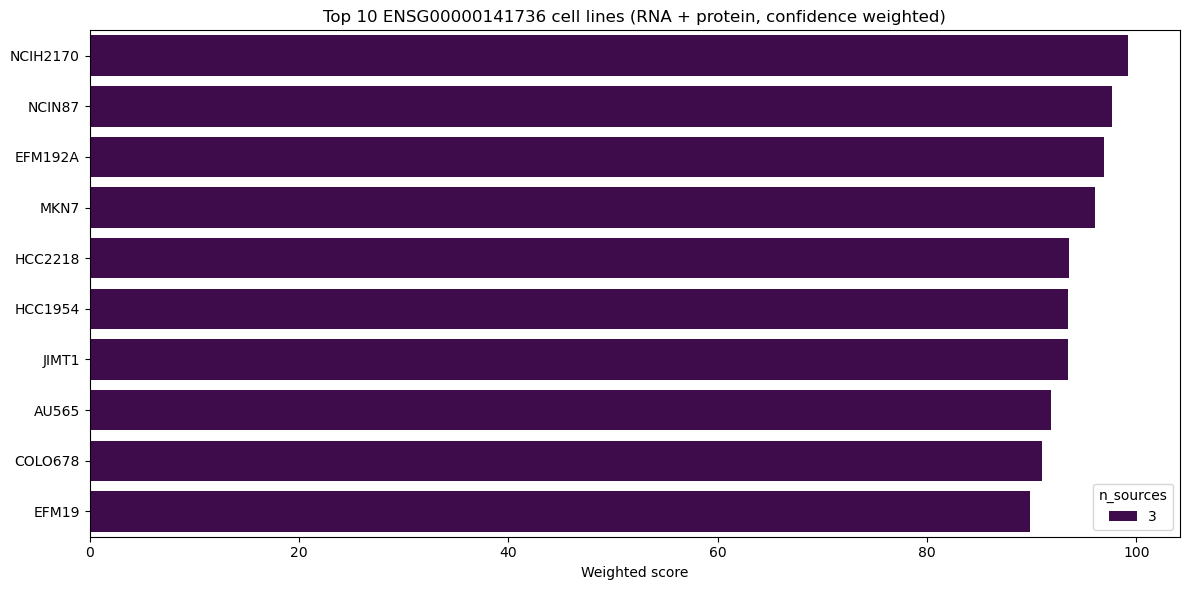

Saved to ../../processed/ENSG00000141736_composite_baseline.parquet


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 = named.sort_values("weighted_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x="weighted_score", y="cell_line_name",
            hue="n_sources", palette="viridis", dodge=False)
plt.title(f"Top 10 {target} cell lines (RNA + protein, confidence weighted)")
plt.xlabel("Weighted score")
plt.ylabel("")
plt.tight_layout()
plt.show()

named.to_parquet(f"../../processed/{target}_composite_baseline.parquet")
print(f"Saved to ../../processed/{target}_composite_baseline.parquet")